In [2]:
import pandas as pd

df = pd.read_csv("Combined Data.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))
print("\nLabel distribution:")
print(df.iloc[:, -1].value_counts())

Shape: (53043, 3)

Columns: ['Unnamed: 0', 'statement', 'status']

First 3 rows:
   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety

Label distribution:
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv("Combined Data.csv")

# Explore
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nLabel distribution:")
print(df["status"].value_counts())
print("\nAny missing values?")
print(df.isnull().sum())

Shape: (53043, 3)

Column names: ['Unnamed: 0', 'statement', 'status']

First 5 rows:
   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety

Label distribution:
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64

Any missing values?
Unnamed: 0      0
statement     362
status          0
dtype: int64


In [4]:


print("Before filtering:", df.shape)
print(df["status"].value_counts())

# ── Filter only the 4 categories we need ──────────────────────────
# Note: dataset has no PTSD, so we use "Stress" as the closest match
category_map = {
    "Depression" : "depression",
    "Anxiety"    : "anxiety",
    "Stress"     : "ptsd",
    "Normal"     : "normal"
}

df = df[df["status"].isin(category_map.keys())].copy()
df["label"] = df["status"].map(category_map)

print("\nAfter filtering:", df.shape)
print("\nNew label distribution:")
print(df["label"].value_counts())
print("\nSample rows:")
print(df[["statement", "label"]].head(5))

Before filtering: (53043, 3)
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64

After filtering: (38312, 4)

New label distribution:
label
normal        16351
depression    15404
anxiety        3888
ptsd           2669
Name: count, dtype: int64

Sample rows:
                                           statement    label
0                                         oh my gosh  anxiety
1  trouble sleeping, confused mind, restless hear...  anxiety
2  All wrong, back off dear, forward doubt. Stay ...  anxiety
3  I've shifted my focus to something else but I'...  anxiety
4  I'm restless and restless, it's been a month n...  anxiety


In [5]:
import re

def anonymize_text(text):
    if not isinstance(text, str):
        return ""
    # Remove emails
    text = re.sub(r"\S+@\S+\.\S+", "[EMAIL]", text)
    # Remove phone numbers
    text = re.sub(r"\b(\+?\d[\d\s\-().]{7,}\d)\b", "[PHONE]", text)
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "[URL]", text)
    # Remove usernames like @someone
    text = re.sub(r"@\w+", "[USER]", text)
    return text

df["statement"] = df["statement"].apply(anonymize_text)

print("Anonymization done!")
print("\nSample after anonymization:")
print(df["statement"].head(5))

Anonymization done!

Sample after anonymization:
0                                           oh my gosh
1    trouble sleeping, confused mind, restless hear...
2    All wrong, back off dear, forward doubt. Stay ...
3    I've shifted my focus to something else but I'...
4    I'm restless and restless, it's been a month n...
Name: statement, dtype: object


In [6]:
pip install nltk


Note: you may need to restart the kernel to use updated packages.


In [7]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK data
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt_tab")

lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words("english"))

# Keep negation words — important for mental health text!
KEEP_WORDS = {
    "no", "not", "never", "nor", "neither",
    "without", "nobody", "nothing", "nowhere",
    "hardly", "barely", "doesn't", "don't",
    "isn't", "wasn't", "won't", "can't"
}
stop_words -= KEEP_WORDS

def clean_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return ""
    # 1. Lowercase
    text = text.lower()
    # 2. Remove special characters
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    # 3. Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    # 4. Tokenize
    tokens = word_tokenize(text)
    # 5. Remove stopwords (keeping negations)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    # 6. Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df["text_clean"] = df["statement"].apply(clean_text)

print("Cleaning done!")
print("\nBefore vs After cleaning:")
print("\nBEFORE:", df["statement"].iloc[1])
print("\nAFTER :", df["text_clean"].iloc[1])

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Cleaning done!

Before vs After cleaning:

BEFORE: trouble sleeping, confused mind, restless heart. All out of tune

AFTER : trouble sleeping confused mind restless heart tune


In [8]:
# Count words in each cleaned post
df["word_count"] = df["text_clean"].apply(lambda x: len(x.split()))

print("Before removing short posts:", df.shape)
print("\nWord count stats:")
print(df["word_count"].describe())

# Remove posts with less than 5 words
df = df[df["word_count"] >= 5].copy()

print("\nAfter removing short posts:", df.shape)
print("\nLabel distribution after filtering:")
print(df["label"].value_counts())

Before removing short posts: (38312, 6)

Word count stats:
count    38312.000000
mean        44.489638
std         67.723749
min          0.000000
25%          6.000000
50%         20.000000
75%         57.000000
max       1818.000000
Name: word_count, dtype: float64

After removing short posts: (30461, 6)

Label distribution after filtering:
label
depression    15153
normal         9152
anxiety        3582
ptsd           2574
Name: count, dtype: int64


In [9]:
# Smallest class size
min_count = df["label"].value_counts().min()
print(f"Smallest class: {min_count} posts")
print("Balancing all classes to this size...\n")

# Undersample each class to match the smallest
df_balanced = (
    df.groupby("label", group_keys=False)
    .apply(lambda x: x.sample(min_count, random_state=42))
    .reset_index(drop=True)
    .sample(frac=1, random_state=42)  # shuffle rows
)

print("After balancing:")
print(df_balanced["label"].value_counts())
print("\nTotal posts:", len(df_balanced))

Smallest class: 2574 posts
Balancing all classes to this size...

After balancing:
label
ptsd          2574
depression    2574
normal        2574
anxiety       2574
Name: count, dtype: int64

Total posts: 10296


C:\Users\hp\AppData\Local\Temp\ipykernel_36424\3858734336.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_count, random_state=42))


In [13]:
import os

# Re-map label column from status
category_map = {
    "Depression" : "depression",
    "Anxiety"    : "anxiety",
    "Stress"     : "ptsd",
    "Normal"     : "normal"
}

df_balanced["label"] = df_balanced["status"].map(category_map)

# Keep only the columns teammates need
df_final = df_balanced[[
    "post_id",
    "text_clean",
    "label",
    "word_count"
]].copy()

# Save to output folder
os.makedirs("output", exist_ok=True)
df_final.to_csv("output/cleaned_labeled_dataset.csv", index=False)

print("Final dataset saved!")
print("\nShape:", df_final.shape)
print("\nLabel distribution:")
print(df_final["label"].value_counts())
print("\nSample rows:")
print(df_final.head(5))

Final dataset saved!

Shape: (10296, 4)

Label distribution:
label
ptsd          2574
depression    2574
normal        2574
anxiety       2574
Name: count, dtype: int64

Sample rows:
      post_id                                         text_clean       label  \
0  post_00000  fck get fckinf break holy sht okay well every ...        ptsd   
1  post_00001  know fact never commit suicide mostly emotiona...  depression   
2  post_00002  alice url raising hell europe '70s '80s day ga...      normal   
3  post_00003  father alcoholic year mom deal entire time lat...        ptsd   
4  post_00004  suffering depression anxiety issue past month ...  depression   

   word_count  
0          76  
1          86  
2          46  
3          32  
4          39  


In [12]:
print(df_balanced.columns.tolist())
print(df_balanced.head(3))

['Unnamed: 0', 'statement', 'status', 'text_clean', 'word_count', 'post_id']
   Unnamed: 0                                          statement      status  \
0       48617  FCK CAN I GET A FCKINF BREAK HOLY SHT Okay wel...      Stress   
1       16998  I know for a fact that Id never commit suicide...  Depression   
2       29466  [Alice <url> was raising hell about it in Euro...      Normal   

                                          text_clean  word_count     post_id  
0  fck get fckinf break holy sht okay well every ...          76  post_00000  
1  know fact never commit suicide mostly emotiona...          86  post_00001  
2  alice url raising hell europe '70s '80s day ga...          46  post_00002  


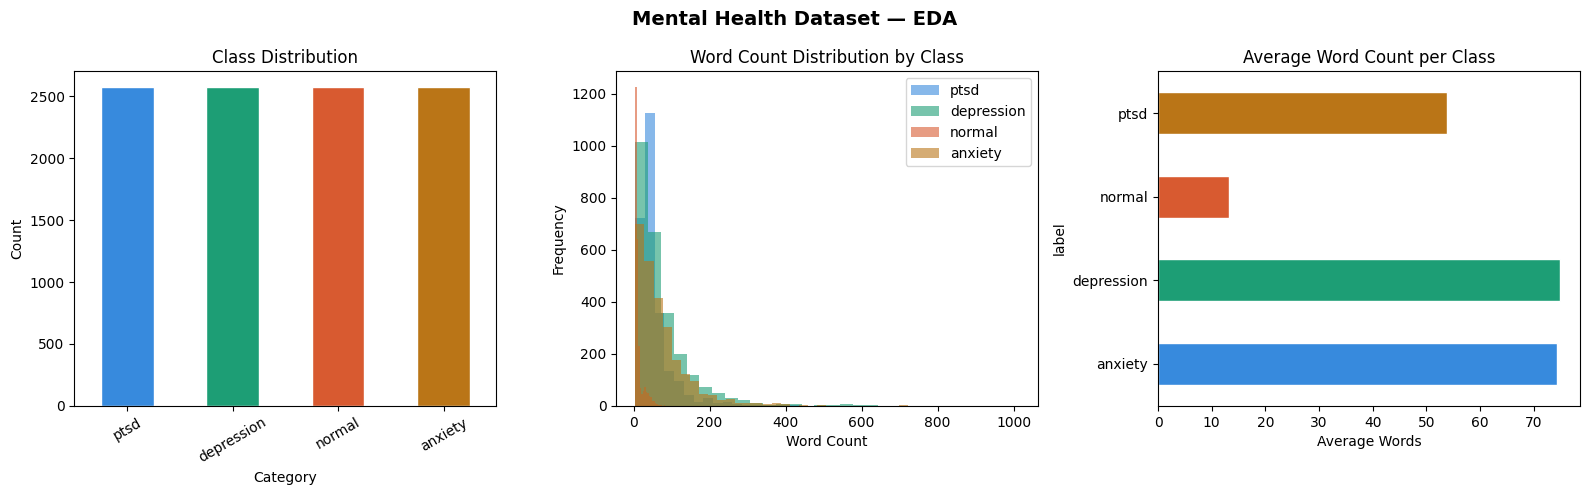

EDA plots saved to output/eda_plots.png!


In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Mental Health Dataset — EDA", fontsize=14, fontweight="bold")

colors = ["#378ADD", "#1D9E75", "#D85A30", "#BA7517"]

# Plot 1 — Class distribution
df_final["label"].value_counts().plot(
    kind="bar", ax=axes[0], color=colors, edgecolor="white"
)
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

# Plot 2 — Word count distribution per class
for label, color in zip(df_final["label"].unique(), colors):
    subset = df_final[df_final["label"] == label]["word_count"]
    axes[1].hist(subset, alpha=0.6, label=label, bins=30, color=color)
axes[1].set_title("Word Count Distribution by Class")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# Plot 3 — Average word count per class
avg_words = df_final.groupby("label")["word_count"].mean()
avg_words.plot(kind="barh", ax=axes[2], color=colors, edgecolor="white")
axes[2].set_title("Average Word Count per Class")
axes[2].set_xlabel("Average Words")

plt.tight_layout()
plt.savefig("output/eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA plots saved to output/eda_plots.png!")